In [189]:
import numpy as np
import pandas as pd
import math
import heapq
import matplotlib.pyplot as plt
from decimal import Decimal
floaterr = 1.0e-8

In [190]:
a = pd.read_csv("./datasets/a280.csv")
# a = pd.read_csv("./minidatasets/minitsp.csv")
# a = pd.read_csv("./datasets/xql662.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [191]:
# distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [193]:
# MST 찾기( 프림 알고리즘 사용)
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

In [194]:
finite_mask = np.isfinite(mstgraph)
total_weight = np.sum(mstgraph[finite_mask]) / 2

print("MST 총 가중치:", total_weight)

MST 총 가중치: 2438.5667409622256


In [195]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[0, 1, 4, 5, 7, 8, 12, 14, 15, 16, 17, 18, 19, 20, 31, 33, 34, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 57, 61, 62, 64, 66, 68, 74, 75, 77, 78, 80, 82, 83, 84, 88, 92, 93, 95, 96, 97, 98, 100, 103, 105, 106, 108, 111, 113, 115, 124, 127, 129, 130, 131, 133, 134, 135, 136, 137, 141, 142, 143, 145, 146, 147, 149, 150, 168, 171, 173, 177, 178, 180, 187, 188, 191, 192, 193, 200, 207, 220, 230, 231, 232, 234, 235, 236, 239, 240, 242, 244, 245, 247, 249, 255, 263, 264, 266, 267, 268, 269, 275, 277, 278, 279]


In [196]:
next_id = len(distance_matrix)

In [197]:
class blossom:
    def __init__(self, G, Id, nodes=None):
        self.Graph = G
        self.Id = Id
        self.Dual = Decimal(0)
        self.Matching = None
        self.Nodes = [] # 블라썸에 포함된 노드들
        
        self.Visited = False
        self.Label = True
        self.parent = None
        self.path = [self] # root 부터 여기까지 온 경로 ( 노드들 )
        self.root = self

        if nodes != None:
            self.Nodes += nodes
        
    def is_blossom(self):
        if len(self.Nodes) >= 3:
            return True
        return False
        
    def add_node(self, v):
        self.Nodes.append(v)
        
    def distance(self, v):
        return self.Graph.distance(self,v)
        
    def slack(self, v):
        return self.Graph.slack(self,v)
        
    def labeling(self): # label visited
        if self.parent == None:
            self.Label = True
        if self.Label != None:
            return
        self.Label = not self.parent.Label
    
    def is_containning(self, node):
        if self.Nodes == []: # base case
            if self == node:
                return True
        
        for x in self.Nodes:
            if x.is_containning(node):
                return True
        return False
    

In [198]:
# 모든 노드는 블라썸 노드로 생각 할 수 있다.
# 사이즈가 1 이면 일반노드, 3 이상의 홀수 노드이면 블라썸이 되는 것.
# 이떄, 
# 1. 블라썸은 자기에 포함된 노드를 가지고 있어야한다.
# 2. 엣지도 알고 있어야한다.
# 3. 블라썸이 생길떄 전체 그래프에서 노드와 엣지를 추가/삭제 해야함.

# 그리고 트리를 관리해야함. 트리는 루트를 알고 있어야하고, 트리의 구성을 알기위해서 어떻게 연결되었는지 찾을 수 있어야함. 맞나?
# 한놈을 고르고 그놈이 augment 될떄까지 그놈만 패면 되니까.
# 트리를 관리하지 말고 한놈을 잡고 그놈이 매칭될때 까지 패면 될듯함.

# lifting 과 expand 구분하기
# augment  할떄는 lifting 만 하면 됌 
# lifting 은 구멍을 v 가 되게 matching 을 구성하게 하자, 지금 블라썸에 1개는 매칭이 없는 상황임 그게 v 가 되게하면 나중에 expanding 할때 매칭 없는놈이랑
# 이어주기만 하면 됌.


    
    
# 트리를 그래프가 하나만 가지고 있고
# 트리는 루트만 가지고 있음 그리고
# 각 노드는 자식과 부모를 알고 있다.
# priaml operation 은 여기에다가 하면 될듯

class blossomgraph:
    def __init__(self, indices):
        self.nodes = [ blossom( self, Id ) for Id in indices ]  # nodes 먼저 생성하고
        self.dist = {}
        self.tight_cache ={}
        
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                self.dist[(n1,n2)] = Decimal( format(distance_matrix[n1.Id][n2.Id], '.15f') )
        
    def distance(self, u, v):
        # 메모되어있음
        if u == v:
            return Decimal(0) 
        if self.dist.get((u,v)) != None:
            return self.dist[(u,v)]
        elif self.dist.get((v,u)) != None:
            return self.dist[(v,u)]

        # 둘 중에 하나만 밖에서 보이는 경우
            #u vnode
        tmp = Decimal('Infinity')
        for unode in u.Nodes:
            searchdist = self.distance(unode, v) - unode.Dual
            if searchdist < tmp:
                tmp = searchdist

        for vnode in v.Nodes:
            searchdist = self.distance(u, vnode) - vnode.Dual
            if searchdist < tmp:
                tmp = searchdist
                
        self.dist[(u,v)] = tmp
        return tmp
        
    def slack(self, u, v):
        return self.distance(u,v) - u.Dual - v.Dual
        

    def update_tightnode(self):
        self.tight_cache.clear()
        for node in self.nodes:
            tight_list = []
            for other in self.nodes:
                if node != other and self.slack(node, other) <= floaterr and self.slack(node, other) >= -floaterr:
                    tight_list.append(other)
            self.tight_cache[node.Id] = tight_list
        

    def tightnode(self,u):
        return self.tight_cache.get(u.Id, [])

    def init_nodes(self):
        for node in self.nodes:
            node.Visited = False
            node.Label = None
            node.parent = None
            
    #일단 u v 연결하는 엣지를 찾아버림, 그리고 그 엣지의 원래 엣지를 찾아. 그다음에 u 에 포함되는거 찾고 v 에 포함되는 거 찾고, 그리고 나서 뭐하냐

    def connect(self,u,v): #u, v 
        u.Matching = v
        v.Matching = u

    def find_cycle(self, u,v): # 인접하는 노드 끼리 인덱스 이웃하게 넣기
        upath =[]
        vpath = []
        upath.append(u)
        vpath.append(v)
        
        cur = u
        while cur.parent != None:
            upath.append( cur.parent )
            cur = cur.parent

        cur = v
        while cur.parent != None:
            vpath.append( cur.parent )
            cur = cur.parent

        cycle = []
        for uindex in range(len(upath)):
            if upath[uindex] in vpath:
                break
        target = upath[uindex]
        cur = u
        while cur != target:
            cycle.append( cur )
            cur = cur.parent

        cycle.append(target)
        
        cur = v
        while cur != target:
            cycle.insert(0, cur )
            cur = cur.parent

        while cycle[0] != target:
            cycle.append( cycle.pop(0) )

        return cycle

    def SHRINK(self, cycle): # 노드 리스트를 받아서 그냥 합치기만 하고 새 블라썸의 값은 처리하지 말자.
        # Cycle: (vertex list, parent)
        global next_id
        newblossom = blossom(self, next_id)
        next_id += 1

        # 노드 처리
        newblossom.Nodes = cycle # 노드안에 담아두고
        self.nodes.append(newblossom) # 그래프에 추가
        for node in cycle: # 그래프에서 제거하기
            self.nodes.remove(node)

        return newblossom

    def EXPAND(self, blossom): #가지고 있던거 밖으로 다 던지고, 그래프에 blossom 적인거 다 지우면 됌.
        # 내부 구조 lifting
        # 매칭과 가장 가까운 노드를 찾기기
        closenode = None
        tmp = Decimal('Infinity')
        for node in blossom.Nodes:
            dist = self.distance(node, blossom.Matching)
            if dist < tmp:
                tmp = dist
                closenode = node
        
        # 그 노드랑 매칭이랑 있고, 나머지는 이웃한놈끼리 이어버림
        
        # 가장 가까운 노드를 0번 인덱스에 위치치
        while blossom.Nodes[0] != closenode:
            blossom.Nodes.append( blossom.Nodes.pop(0) )

        # 가장 가까운 노드를 매칭이랑 연결
        
        blossom.Nodes[0].Matching = blossom.Matching
        blossom.Matching.Matching = blossom.Nodes[0]

        for idx in range(1, len(blossom.Nodes) -1 , 2):
            self.connect( blossom.Nodes[idx], blossom.Nodes[idx+1] )

        #블라썸 삭제 #가지고 있던 노드를 복구
        self.nodes.remove(blossom)

        for node in blossom.Nodes:
            self.nodes.append(node)

    def bfs(self, root): #bfs 하고 cycle 생기면 블라썸 만들어버리는 것 까지. grow augment shrink expand
        for node in self.nodes:
            node.Visited = False

        queue = []
        root.Label = True
        root.root = root
        root.path = [root]

        queue.append(root)
        root.Visited = True
        
        print("root id : ", root.Id)

        while queue:
            curnode = queue.pop(0) # + 인 애들임
            
            print("curnode : ",curnode.Id)
            print("tight nodes : ", [ x.Id for x in self.tightnode(curnode)] )
            for node in [node for node in self.tightnode(curnode) if node.Matching != curnode]:
                if curnode.Label == True and node.Label == True and node.root == curnode.root: # shrink
                    print("shrink")
                    
                    cycle = self.find_cycle(curnode, node)

                    newblossom = self.SHRINK(cycle)
                    
                    newblossom.root = curnode.root
                    newblossom.path = curnode.path + [newblossom]
                    newblossom.Visited = True
                    newblossom.labeling()                    
                    newblossom.parent = cycle[0].parent
                    
                    if newblossom.parent != None:
                        newblossom.Matching = newblossom.parent
                        newblossom.Matching.Matching = newblossom
                    else:
                        newblossom.Matching = None


                    if root in cycle:
                        newblossom.root = newblossom
                        newblossom.path = [newblossom]

                    self.bfsall()
                    return

                elif node.Label == True and curnode.Label == True and node.root != curnode.root: # augment
                    print("augment" , node.Id)

                    augpath = curnode.path
                    for x in range(len(node.path)-1,-1,-1):
                        augpath.append( node.path[x] )
                    print("augpath", [x.Id for x in augpath])

                    self.free(curnode.root)
                    self.free(node.root)

                    for idx in range(0, len(augpath),2):
                        u = augpath[idx]
                        v = augpath[idx+1]
                        self.connect(u,v)

                        u.Label = None
                        u.path = []
                        u.parent = None
                        u.Visited = False
                        u.root = None

                        v.Label = None
                        v.path = []
                        v.parent = None
                        v.Visited = False
                        v.root = None

                    return 1
                    


                elif ( node.Label == None and node.Matching != None ): # grow
                    print("grow" , node.Id)
                    
                    node.parent = curnode
                    node.Matching.parent = node
    
                    node.labeling()
                    node.Matching.labeling()

                    node.Visited = True
                    node.Matching.Visited = True
                    queue.append(node.Matching)

                    node.root = curnode.root
                    node.Matching.root = curnode.root

                    node.path = curnode.path + [node]
                    node.Matching.path = node.path + [node.Matching]

                    if node.Label == False and node.is_blossom() and node.Dual == 0:
                        self.EXPAND(node)
                        self.bfsall()
                        return
                else:
                    print("bfs err")


                # if node.Label == True and node.root == curnode.root: # shrink

        return 0
    
    def bfsall(self):
        self.update_tightnode()
        for node in self.nodes:
                node.parent = None
                node.Label = None
                node.Visited = None
                node.root = None
        freenode = [x for x in self.nodes if x.Matching == None]
        for node in freenode:
            if node.Matching != None:
                    continue
            self.bfs(node)

    def updatedual(self):
        delta = Decimal('Infinity')
        pnodes = [ node for node in self.nodes if node.Label == True ]
        blossom = [ node for node in self.nodes if node.is_blossom() and node.Label == False]
        freenodes = [ node for node in self.nodes if node.Label == None ]
        case = None
        tmp = None
        nextroot = None
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                elif (n1.Label == True and n2.Label == None) or (n1.Label == None and n2.Label == True):
                    if delta > self.slack(n1, n2):
                        delta = self.slack(n1, n2)
                        case = "grow"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root if n1.Label == True else n2.root
                elif (n1.root != n2.root) and (n1.Label == True and n2.Label == True):
                    if delta > self.slack(n1, n2) / 2:
                        delta = self.slack(n1, n2)/2
                        case = "augment"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root
                elif (n1.Label == True and n2.Label == True) and (n1.root == n2.root):
                    if delta > self.slack(n1, n2) / 2:
                        delta = self.slack(n1, n2) / 2
                        case = "shrink"
                        tmp = (n1.Id, n2.Id)
                        nextroot = n1.root

        for b1 in blossom:
            if b1.Label == True:
                continue
            if b1.Label == False and delta > b1.Dual:
                    case = "Expand"
                    delta = b1.Dual
                    tmp = b1.Id
                    nextroot = b1.root
    

        print( case, tmp )
        for node in self.nodes:
            if node.Label == True:
                node.Dual += delta
            elif node.Label == False:
                node.Dual -= delta

        return nextroot

    def free(self, root):
        for node in self.nodes:
            if node.root == root:
                node.Label = None
                node.path = []
                node.parent = None
                node.Visited = False
                

    def find_min_weight_matching(self):
        #init dual - greedy
        # 최소거리의 절반으로 먼저 셋팅함

        for node in self.nodes:
            m = Decimal('Infinity')
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.distance(To):
                    m = node.distance(To)
            node.Dual = m / 2
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if self.slack(n1, n2) < floaterr and self.slack(n1, n2) > -floaterr and n1.Matching == None and n2.Matching == None:
                    self.connect(n1, n2)
                    n1.Label = None
                    n1.path = []
                    n1.parent = None
                    n1.Visited = False
                    n2.Label = None
                    n2.path = []
                    n2.parent = None
                    n2.Visited = False
                    n1.root = None
                    n2.root = None
        return


f = blossomgraph(odd_rows)
f.find_min_weight_matching()


In [199]:
# def get_node_pos(node, points, pos_cache):
#     # 이미 계산된 경우 캐시 사용
#     if node.Id in pos_cache:
#         return pos_cache[node.Id]
#     if not node.is_blossom():
#         pos_cache[node.Id] = tuple(points[node.Id])
#         return pos_cache[node.Id]
#     # blossom 노드라면 내부 노드들의 좌표 평균
#     xs, ys = [], []
#     for n in node.Nodes:
#         x, y = get_node_pos(n, points, pos_cache)
#         xs.append(x)
#         ys.append(y)
#     pos_cache[node.Id] = (np.mean(xs), np.mean(ys))
#     return pos_cache[node.Id]

def get_node_pos(node, points, pos_cache):
    """
    node      : blossomgraph의 노드 객체
    points    : 원본 점들의 (N,2) NumPy 배열
    pos_cache : 계산된 위치를 저장하는 dict
    """
    # 1) 캐시에 있으면 바로 반환
    if node.Id in pos_cache:
        return pos_cache[node.Id]
    
    # 2) 원본 노드인 경우 (ID가 points 범위 안에 있을 때)
    if node.Id < len(points):
        pos_cache[node.Id] = tuple(points[node.Id])
        return pos_cache[node.Id]
    
    # 3) 블라썸 노드인 경우: 내부 노드들의 좌표 평균
    xs, ys = [], []
    for n in node.Nodes:
        x, y = get_node_pos(n, points, pos_cache)
        xs.append(x)
        ys.append(y)
    pos_cache[node.Id] = (np.mean(xs), np.mean(ys))
    return pos_cache[node.Id]

# def visualize(f, points):
#     # 노드별 위치 계산
#     pos_cache = {}
#     for node in f.nodes:
#         get_node_pos(node, points, pos_cache)

#     # 나머지 시각화 로직은 그대로...
#     plt.figure(figsize=(10, 10))
#     # 매칭 간선, 타이트 간선, 노드 원 그리기 등


def visualize(f, points):
    """
    f      : blossomgraph 인스턴스
    points : 각 원래 노드(Id)에 대응하는 (x, y) 좌표를 담은 dict 또는 배열
    """
    # 1) 노드별 위치 계산(pos): 블라썸이면 포함된 노드들의 평균 위치
    pos = {}
    for node in f.nodes:
        get_node_pos(node, points, pos)
        
    # pos = {}
    # for node in f.nodes:
    #     if node.is_blossom():
    #         xs = [points[n.Id][0] for n in node.Nodes]
    #         ys = [points[n.Id][1] for n in node.Nodes]
    #         pos[node.Id] = (np.mean(xs), np.mean(ys))
    #     else:
    #         pos[node.Id] = tuple(points[node.Id])

    plt.figure(figsize=(10, 10))

    # 2) 매칭 간선 먼저 그리기 (두꺼운 검은 선)
    drawn = set()
    for node in f.nodes:
        match = node.Matching
        if match is not None and (node.Id, match.Id) not in drawn:
            x1, y1 = pos[node.Id]
            x2, y2 = pos[match.Id]
            plt.plot([x1, x2], [y1, y2],
                     color='k', linewidth=4)
            drawn.add((node.Id, match.Id))
            drawn.add((match.Id, node.Id))
            
    for node in f.nodes:
        for tnode in f.tightnode(node):
            if node.Id < tnode.Id:  # 중복 방지
                x1, y1 = pos[node.Id]
                x2, y2 = pos[tnode.Id]
                plt.plot([x1, x2], [y1, y2], color='b', linestyle='dashed', linewidth=1, alpha=0.5)
    # 3) 노드(원 + 점 + 아이디) 그리기
    ax = plt.gca()
    for node in f.nodes:
        x, y = pos[node.Id]
        radius = node.Dual
        circle = plt.Circle((x, y), radius,
                            color='b', fill=False, alpha=0.5)
        ax.add_patch(circle)
        plt.plot(x, y, 'ro')
        plt.text(x, y, str(node.Id),
                 fontsize=12, ha='right', va='bottom',
                 color='black')

    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X'); plt.ylabel('Y')
    plt.axis('equal'); plt.grid(True)
    plt.show()

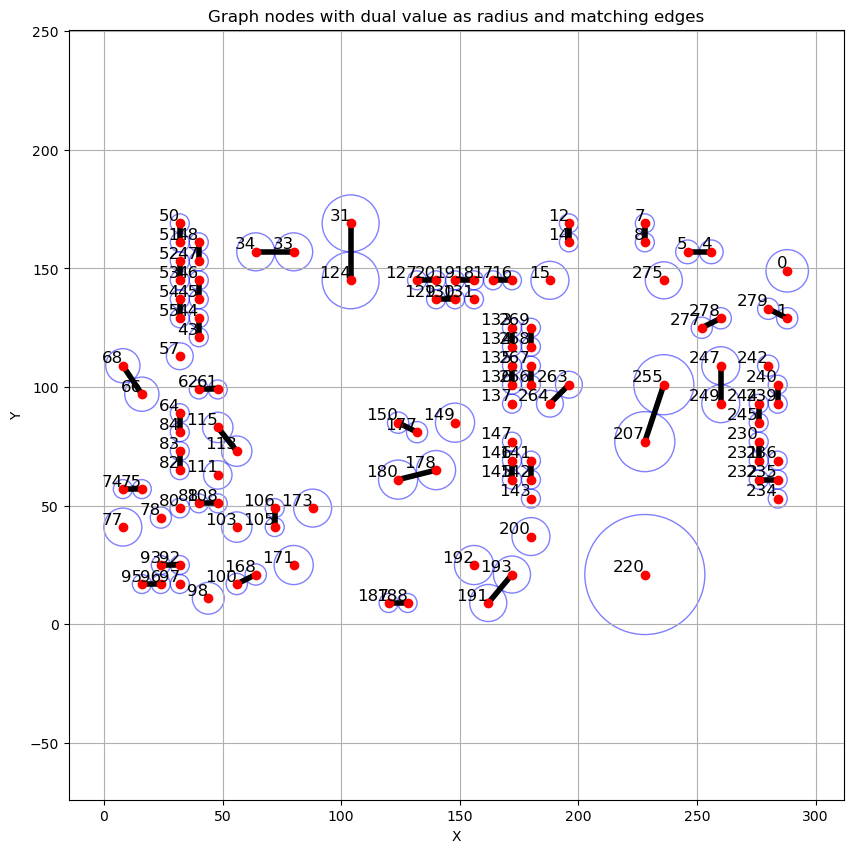

In [200]:
visualize(f,points)

In [201]:
def printnodes():
    for x in f.nodes:
        if x.root == None:
            if x.Matching == None:
                print("Id : ",x.Id, x.Matching,"\n    Root : ", x.root,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
            else:
                print("Id : ",x.Id, x.Matching.Id,"\n    Root : ", x.root,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
        else:
            if x.Matching == None:
                print("Id : ",x.Id, x.Matching,"\n    Root : ", x.root.Id,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])
            else:
                print("Id : ",x.Id, x.Matching.Id,"\n    Root : ", x.root.Id,"\n    Label : ", x.Label, "\n    path: ", [ y.Id for y in x.path])

printnodes()

Id :  0 None 
    Root :  0 
    Label :  True 
    path:  [0]
Id :  1 279 
    Root :  None 
    Label :  None 
    path:  []
Id :  4 5 
    Root :  None 
    Label :  None 
    path:  []
Id :  5 4 
    Root :  None 
    Label :  None 
    path:  []
Id :  7 8 
    Root :  None 
    Label :  None 
    path:  []
Id :  8 7 
    Root :  None 
    Label :  None 
    path:  []
Id :  12 14 
    Root :  None 
    Label :  None 
    path:  []
Id :  14 12 
    Root :  None 
    Label :  None 
    path:  []
Id :  15 None 
    Root :  15 
    Label :  True 
    path:  [15]
Id :  16 17 
    Root :  None 
    Label :  None 
    path:  []
Id :  17 16 
    Root :  None 
    Label :  None 
    path:  []
Id :  18 19 
    Root :  None 
    Label :  None 
    path:  []
Id :  19 18 
    Root :  None 
    Label :  None 
    path:  []
Id :  20 127 
    Root :  None 
    Label :  None 
    path:  []
Id :  31 124 
    Root :  None 
    Label :  None 
    path:  []
Id :  33 34 
    Root :  None 
    Label :  N

root id :  0
curnode :  0
tight nodes :  []
root id :  15
curnode :  15
tight nodes :  []
root id :  57
curnode :  57
tight nodes :  []
root id :  77
curnode :  77
tight nodes :  []
root id :  78
curnode :  78
tight nodes :  []
root id :  80
curnode :  80
tight nodes :  []
root id :  97
curnode :  97
tight nodes :  [92, 96]
grow 92
grow 96
curnode :  93
tight nodes :  [92, 96]
bfs err
curnode :  95
tight nodes :  [96]
root id :  98
curnode :  98
tight nodes :  []
root id :  103
curnode :  103
tight nodes :  []
root id :  111
curnode :  111
tight nodes :  []
root id :  131
curnode :  131
tight nodes :  [18, 130]
grow 18
grow 130
curnode :  19
tight nodes :  [18, 20, 130]
grow 20
bfs err
curnode :  129
tight nodes :  [20, 130]
bfs err
curnode :  127
tight nodes :  [20]
root id :  137
curnode :  137
tight nodes :  [136]
grow 136
curnode :  135
tight nodes :  [134, 136, 267]
grow 134
grow 267
curnode :  133
tight nodes :  [134, 269]
grow 269
curnode :  266
tight nodes :  [136, 267]
bfs err

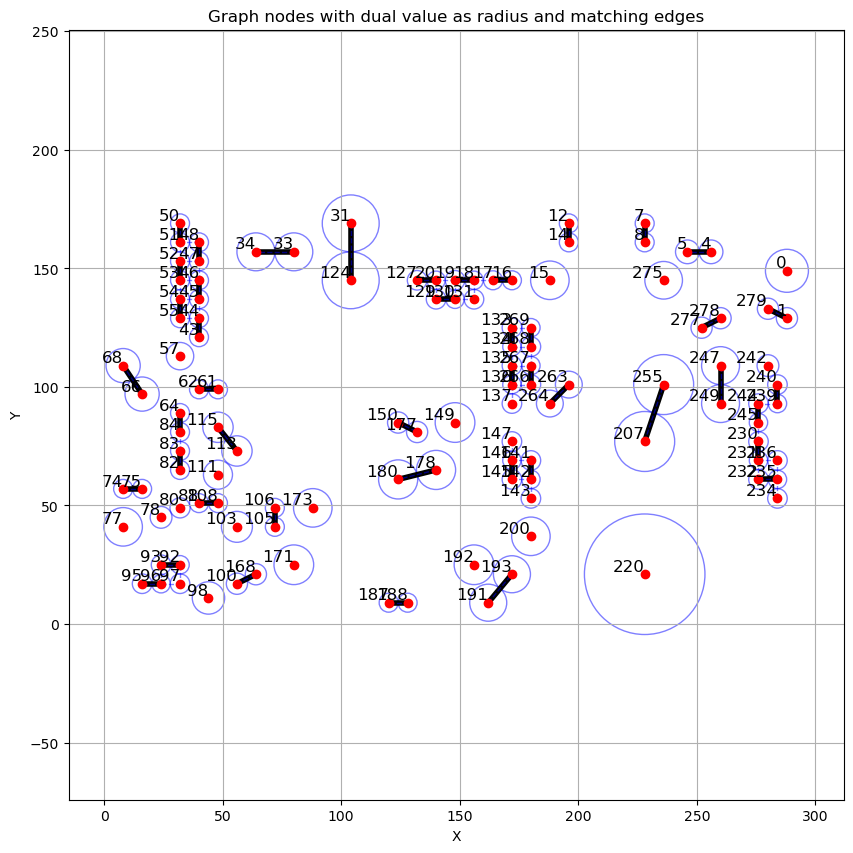

In [202]:
f.bfsall()
print(f.updatedual())

visualize(f,points)

In [203]:
while 1:
    f.bfsall()
    cond = f.updatedual()
    # visualize(f,points)
    if cond == None:
        break

root id :  0
curnode :  0
tight nodes :  []
root id :  15
curnode :  15
tight nodes :  []
root id :  57
curnode :  57
tight nodes :  []
root id :  77
curnode :  77
tight nodes :  []
root id :  78
curnode :  78
tight nodes :  []
root id :  80
curnode :  80
tight nodes :  [88]
grow 88
curnode :  108
tight nodes :  [88]
root id :  97
curnode :  97
tight nodes :  [92, 96]
grow 92
grow 96
curnode :  93
tight nodes :  [92, 96]
bfs err
curnode :  95
tight nodes :  [96]
root id :  98
curnode :  98
tight nodes :  []
root id :  103
curnode :  103
tight nodes :  []
root id :  111
curnode :  111
tight nodes :  []
root id :  131
curnode :  131
tight nodes :  [18, 130]
grow 18
grow 130
curnode :  19
tight nodes :  [18, 20, 130]
grow 20
bfs err
curnode :  129
tight nodes :  [20, 130]
bfs err
curnode :  127
tight nodes :  [20]
root id :  137
curnode :  137
tight nodes :  [136]
grow 136
curnode :  135
tight nodes :  [134, 136, 267]
grow 134
grow 267
curnode :  133
tight nodes :  [134, 269]
grow 269
cur

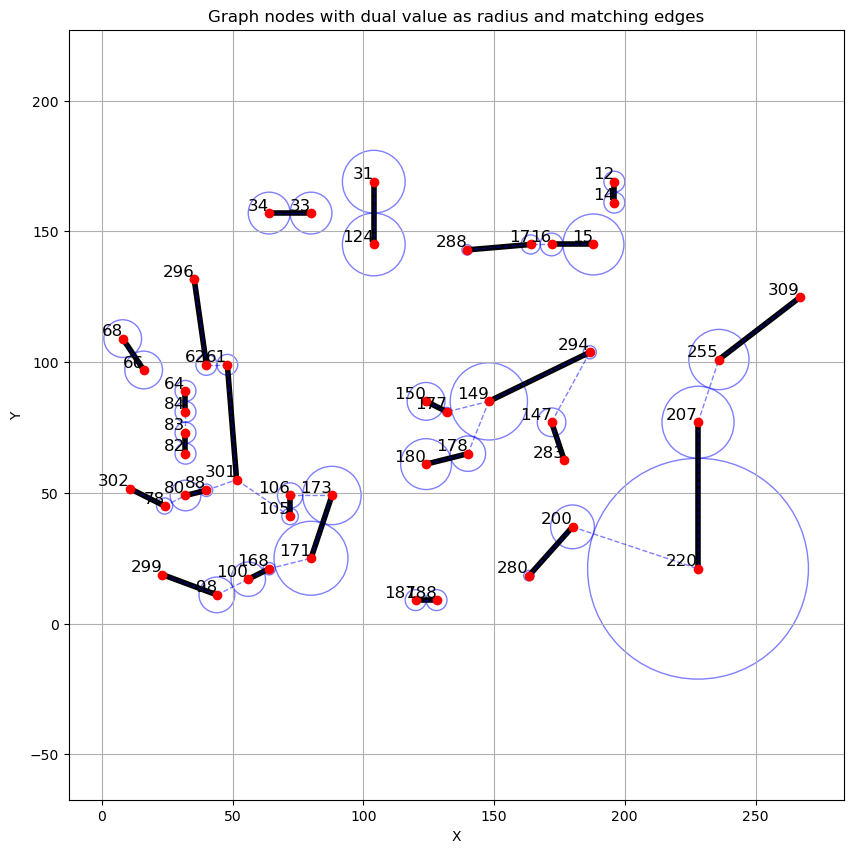

In [204]:
visualize(f,points)

In [205]:
blossom = []
for node in f.nodes:
    if node.is_blossom():
        blossom.append(node)
blossom.sort(key=lambda x: x.Id)
if blossom != []:
    blossom = blossom[0] # 원래 -1
    f.EXPAND(blossom)
    # visualize(f,points)
while blossom != []:
    blossom = []
    for node in f.nodes:
        if node.is_blossom():
            blossom.append(node)
    blossom.sort(key=lambda x: x.Id)
    if blossom != []:
        blossom = blossom[-1]
        f.EXPAND(blossom)
        # visualize(f,points)

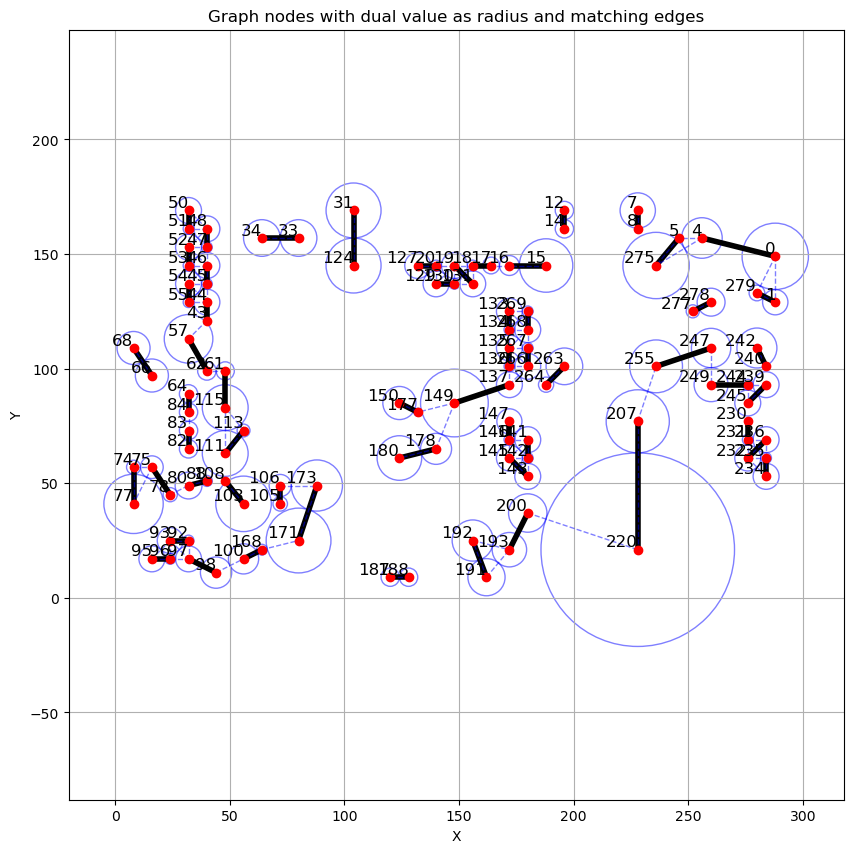

In [206]:
f.update_tightnode()
visualize(f,points)

In [207]:
len( odd_rows)

114

In [208]:
sum =0
for x in f.nodes:
    if x.Matching != None:
        sum += distance_matrix[x.Id][x.Matching.Id] # f.distance(x, x.Matching)
    else:
        print("err")


In [209]:
print("sum : ", sum/2)

sum :  729.5029258250943


In [210]:
matching = []
for x in f.nodes:
    if x.Matching.Id > x.Id:
        matching.append( (x.Id, x.Matching.Id) )

matching.sort( key=lambda x: x[0] )
matching

[(0, 4),
 (1, 279),
 (5, 275),
 (7, 8),
 (12, 14),
 (15, 16),
 (17, 18),
 (19, 131),
 (20, 127),
 (31, 124),
 (33, 34),
 (43, 44),
 (45, 46),
 (47, 48),
 (50, 51),
 (52, 53),
 (54, 55),
 (57, 62),
 (61, 115),
 (64, 84),
 (66, 68),
 (74, 77),
 (75, 78),
 (80, 88),
 (82, 83),
 (92, 93),
 (95, 96),
 (97, 98),
 (100, 168),
 (103, 108),
 (105, 106),
 (111, 113),
 (129, 130),
 (133, 134),
 (135, 136),
 (137, 149),
 (141, 142),
 (143, 145),
 (146, 147),
 (150, 177),
 (171, 173),
 (178, 180),
 (187, 188),
 (191, 192),
 (193, 200),
 (207, 220),
 (230, 231),
 (232, 236),
 (234, 235),
 (239, 245),
 (240, 242),
 (244, 249),
 (247, 255),
 (263, 264),
 (266, 267),
 (268, 269),
 (277, 278)]

In [211]:
mark = {}
for x in odd_rows:
    mark[x] = False

for node in f.nodes:
    mark[node.Id] = True
    mark[node.Matching.Id] = True

for node in f.nodes:
    if node != node.Matching.Matching:
        print("err")


In [212]:
nodes = []
edges=[]
for x in range( len(mstgraph) ):
    for y in range( len(mstgraph) ):
        if x >= y:
            continue
        if mstgraph[x][y] != np.inf:
            edges.append( (x,y) )
for x in range(len(mstgraph)):
    nodes.append(x)
    
edges = edges+matching
print(edges)
print(nodes)

[(0, 279), (1, 279), (2, 278), (2, 279), (3, 276), (3, 278), (4, 5), (5, 6), (5, 275), (6, 7), (7, 8), (7, 9), (9, 10), (10, 11), (11, 12), (12, 13), (12, 14), (13, 23), (15, 270), (16, 17), (17, 18), (17, 132), (18, 19), (18, 131), (19, 20), (19, 130), (20, 127), (20, 129), (21, 24), (21, 25), (22, 23), (22, 24), (25, 26), (26, 27), (27, 28), (28, 30), (29, 30), (29, 124), (30, 31), (30, 32), (32, 33), (34, 35), (35, 36), (36, 37), (37, 38), (38, 39), (39, 40), (40, 41), (41, 42), (42, 59), (43, 44), (43, 56), (43, 58), (44, 45), (44, 55), (45, 46), (45, 54), (46, 47), (46, 53), (47, 48), (47, 52), (48, 49), (48, 51), (49, 50), (56, 57), (58, 62), (59, 60), (60, 117), (61, 62), (62, 63), (63, 64), (64, 65), (64, 84), (65, 66), (66, 67), (66, 69), (67, 68), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (74, 76), (76, 77), (78, 79), (79, 80), (80, 81), (80, 88), (81, 82), (82, 83), (82, 87), (83, 84), (83, 86), (84, 85), (85, 115), (86, 112), (87, 111), (88, 89), (88, 108)

In [213]:
def find_eulerian_circuit(nodes, edges):
    stack = [nodes[0]]
    result =[]
    while stack:
        node = stack[-1]
        found = False
        for edge in edges:
            if edge[0] == node:
                stack.append(edge[1])
                edges.remove(edge)
                found = True
                break
            elif edge[1] == node:
                stack.append(edge[0])
                edges.remove(edge)
                found = True
                break
        if not found:
            result.append(stack.pop())
    return result

In [214]:
e_path = find_eulerian_circuit(nodes, edges)

In [215]:
short_cutting = []
for i in range(len(e_path) - 1):
    if e_path[i] not in short_cutting:
        short_cutting.append(e_path[i])

In [216]:
dist = 0
for i in range(len(short_cutting) -1):
    dist += distance_matrix[short_cutting[i]][short_cutting[i+1]]

In [217]:
dist

2980.3978324185136